# 🩺 SPK Diabetes Melitus Tipe 2: AHP + TOPSIS
**Sistem Pendukung Keputusan untuk Rekomendasi Penatalaksanaan Diabetes**

Universitas Internasional Semen Indonesia — Informatika

---

### 📚 Referensi Jurnal
| Kriteria | Referensi |
|---|---|
| C1 Efektivitas | ADA, *Standards of Care in Diabetes—2023*, Diabetes Care, 2023. https://doi.org/10.2337/dc23-Srev |
| C2 Biaya | Li et al., *Cost-Effectiveness of Interventions*, Diabetes Care, 2010. https://doi.org/10.2337/dc10-0843 |
| C3 Kemudahan | Khunti et al., *Patient Adherence*, J. Diabetes, 2024. https://pubmed.ncbi.nlm.nih.gov/PMC12040741 |
| C4 Efek Samping | Davies et al., *ADA–EASD Consensus*, Diabetes Care, 2022. https://doi.org/10.2337/dci22-0034 |
| C5 Kecepatan | Holman et al., *10-Year Follow-up*, NEJM, 2008. https://doi.org/10.1056/NEJMoa0806470 |
| MCDM Diabetes | Jaberidoost et al., *MCDM Systematic Review*, JMIR, 2024. https://medinform.jmir.org/2024/1/e47701 |
| TOPSIS Diabetes | Wu et al., *CDSS Diabetes TOPSIS*, J. Med. Syst., 2018. https://doi.org/10.1007/s10916-017-0881-4 |

In [3]:
# ============================================================
# CELL 1: Install & Import Libraries
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Styling
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


---
## BAGIAN 1 — Definisi Alternatif & Kriteria

In [4]:
# ============================================================
# CELL 2: Definisi Alternatif dan Kriteria
# ============================================================

# --- Alternatif ---
alternatives = [
    'A1: Diet Rendah Karb + Olahraga',
    'A2: Konsultasi Dokter + HbA1c',
    'A3: Metformin + Monitor Gula Darah',
    'A4: Program Penurunan Berat Badan',
    'A5: Intervensi Gaya Hidup Intensif'
]

# --- Kriteria ---
criteria = [
    'C1: Efektivitas (%)',
    'C2: Biaya (Rp rb/bln)',
    'C3: Kemudahan (1-10)',
    'C4: Efek Samping (1-10)',
    'C5: Kecepatan (bln)'
]

# Tipe: 'benefit' (makin besar makin baik) / 'cost' (makin kecil makin baik)
criteria_type = ['benefit', 'cost', 'benefit', 'cost', 'cost']

# --- Matriks Keputusan (Decision Matrix) ---
# Baris = Alternatif, Kolom = Kriteria
decision_matrix = np.array([
    [80,  150, 8, 2, 3],   # A1
    [75,  200, 6, 1, 1],   # A2
    [90,  350, 7, 5, 1],   # A3
    [70,  100, 9, 1, 4],   # A4
    [88,  500, 5, 2, 2],   # A5
], dtype=float)

df_decision = pd.DataFrame(
    decision_matrix,
    index=[f'A{i+1}' for i in range(5)],
    columns=['C1','C2','C3','C4','C5']
)

print('=' * 55)
print('       MATRIKS KEPUTUSAN (Decision Matrix)')
print('=' * 55)
print(df_decision.to_string())
print()
print('Tipe Kriteria:')
for c, t in zip(['C1','C2','C3','C4','C5'], criteria_type):
    print(f'  {c}: {t.upper()}')

       MATRIKS KEPUTUSAN (Decision Matrix)
      C1     C2   C3   C4   C5
A1  80.0  150.0  8.0  2.0  3.0
A2  75.0  200.0  6.0  1.0  1.0
A3  90.0  350.0  7.0  5.0  1.0
A4  70.0  100.0  9.0  1.0  4.0
A5  88.0  500.0  5.0  2.0  2.0

Tipe Kriteria:
  C1: BENEFIT
  C2: COST
  C3: BENEFIT
  C4: COST
  C5: COST


---
## BAGIAN 2 — AHP: Penentuan Bobot Kriteria

**Referensi:** Saaty, T.L. (1980). *The Analytic Hierarchy Process.* McGraw-Hill.

**Skala Saaty:**
| Nilai | Arti |
|---|---|
| 1 | Sama penting |
| 2 | Sedikit lebih penting |
| 3 | Cukup lebih penting |
| 4 | Lebih penting |
| 5 | Sangat lebih penting |
| 7 | Jauh lebih penting |
| 9 | Mutlak lebih penting |

In [5]:
# ============================================================
# CELL 3: Matriks Perbandingan Berpasangan AHP
# ============================================================

# Matriks perbandingan berpasangan (5x5)
# Baris i vs Kolom j: seberapa penting i dibanding j
# Nilai > 1: baris lebih penting; < 1: kolom lebih penting
#
#        C1    C2    C3    C4    C5
# C1  [  1,    2,    2,    2,    2  ]  -> Efektivitas sedikit lebih penting
# C2  [1/2,    1,    2,    1,    2  ]  -> Biaya = Efek samping
# C3  [1/2,  1/2,    1,  1/2,    1  ]  -> Kemudahan = Kecepatan
# C4  [1/2,    1,    2,    1,    2  ]  -> Efek samping = Biaya
# C5  [1/2,  1/2,    1,  1/2,    1  ]  -> Kecepatan = Kemudahan

ahp_matrix = np.array([
    [1,   2,   2,   2,   2],
    [1/2, 1,   2,   1,   2],
    [1/2, 1/2, 1,   1/2, 1],
    [1/2, 1,   2,   1,   2],
    [1/2, 1/2, 1,   1/2, 1],
], dtype=float)

n = ahp_matrix.shape[0]

df_ahp = pd.DataFrame(
    ahp_matrix,
    index=['C1','C2','C3','C4','C5'],
    columns=['C1','C2','C3','C4','C5']
)

print('=' * 55)
print('  MATRIKS PERBANDINGAN BERPASANGAN (AHP)')
print('=' * 55)
print(df_ahp.round(4).to_string())

# Jumlah kolom
col_sums = ahp_matrix.sum(axis=0)
print(f'\nJumlah per kolom: {col_sums.round(4)}')

  MATRIKS PERBANDINGAN BERPASANGAN (AHP)
     C1   C2   C3   C4   C5
C1  1.0  2.0  2.0  2.0  2.0
C2  0.5  1.0  2.0  1.0  2.0
C3  0.5  0.5  1.0  0.5  1.0
C4  0.5  1.0  2.0  1.0  2.0
C5  0.5  0.5  1.0  0.5  1.0

Jumlah per kolom: [3. 5. 8. 5. 8.]


In [6]:
# ============================================================
# CELL 4: Normalisasi AHP & Hitung Bobot
# ============================================================

# Step 1: Normalisasi — bagi setiap elemen dengan jumlah kolomnya
norm_matrix = ahp_matrix / col_sums

df_norm = pd.DataFrame(
    norm_matrix,
    index=['C1','C2','C3','C4','C5'],
    columns=['C1','C2','C3','C4','C5']
)
print('MATRIKS TERNORMALISASI:')
print(df_norm.round(4).to_string())

# Step 2: Bobot = rata-rata setiap baris
weights_raw = norm_matrix.mean(axis=1)

# Step 3: Finalisasi bobot (dibulatkan, disesuaikan pakar agar total = 1)
weights_final = np.array([0.30, 0.20, 0.15, 0.20, 0.15])

print('\n' + '=' * 55)
print('           HASIL BOBOT KRITERIA (AHP)')
print('=' * 55)
print(f'{"Kriteria":<30} {"Bobot Hitung":>12} {"Bobot Final":>12}')
print('-' * 55)
crit_labels = ['C1: Efektivitas','C2: Biaya','C3: Kemudahan','C4: Efek Samping','C5: Kecepatan']
for label, wr, wf in zip(crit_labels, weights_raw, weights_final):
    print(f'{label:<30} {wr:>12.4f} {wf:>12.2f}')
print('-' * 55)
print(f'{"TOTAL":<30} {weights_raw.sum():>12.4f} {weights_final.sum():>12.2f}')

MATRIKS TERNORMALISASI:
        C1   C2     C3   C4     C5
C1  0.3333  0.4  0.250  0.4  0.250
C2  0.1667  0.2  0.250  0.2  0.250
C3  0.1667  0.1  0.125  0.1  0.125
C4  0.1667  0.2  0.250  0.2  0.250
C5  0.1667  0.1  0.125  0.1  0.125

           HASIL BOBOT KRITERIA (AHP)
Kriteria                       Bobot Hitung  Bobot Final
-------------------------------------------------------
C1: Efektivitas                      0.3267         0.30
C2: Biaya                            0.2133         0.20
C3: Kemudahan                        0.1233         0.15
C4: Efek Samping                     0.2133         0.20
C5: Kecepatan                        0.1233         0.15
-------------------------------------------------------
TOTAL                                1.0000         1.00


In [7]:
# ============================================================
# CELL 5: Uji Konsistensi AHP (Consistency Ratio)
# ============================================================

# Random Index (RI) untuk n = 1..10 (Saaty, 1980)
RI_table = {1:0.00, 2:0.00, 3:0.58, 4:0.90, 5:1.12, 6:1.24, 7:1.32, 8:1.41, 9:1.45, 10:1.49}

# 1. Weighted sum vector: A * w
weighted_sum = ahp_matrix @ weights_raw

# 2. Lambda vector: weighted_sum / w
lambda_vec = weighted_sum / weights_raw
lambda_max = lambda_vec.mean()

# 3. Consistency Index
CI = (lambda_max - n) / (n - 1)

# 4. Consistency Ratio
RI = RI_table[n]
CR = CI / RI

print('=' * 55)
print('         UJI KONSISTENSI AHP')
print('=' * 55)
print(f'  λ (lambda) per kriteria : {lambda_vec.round(4)}')
print(f'  λmax                    : {lambda_max:.4f}')
print(f'  n (jumlah kriteria)     : {n}')
print(f'  CI = (λmax - n)/(n-1)  : {CI:.4f}')
print(f'  RI (n={n})              : {RI}')
print(f'  CR = CI / RI            : {CR:.4f}')
print()
if CR < 0.10:
    print(f'  ✅ CR = {CR:.4f} < 0.10  →  KONSISTEN')
    print('     Penilaian pakar dapat diterima!')
else:
    print(f'  ❌ CR = {CR:.4f} >= 0.10 →  TIDAK KONSISTEN')
    print('     Matriks perbandingan perlu direvisi!')

         UJI KONSISTENSI AHP
  λ (lambda) per kriteria : [5.1224 5.0781 5.0541 5.0781 5.0541]
  λmax                    : 5.0774
  n (jumlah kriteria)     : 5
  CI = (λmax - n)/(n-1)  : 0.0193
  RI (n=5)              : 1.12
  CR = CI / RI            : 0.0173

  ✅ CR = 0.0173 < 0.10  →  KONSISTEN
     Penilaian pakar dapat diterima!


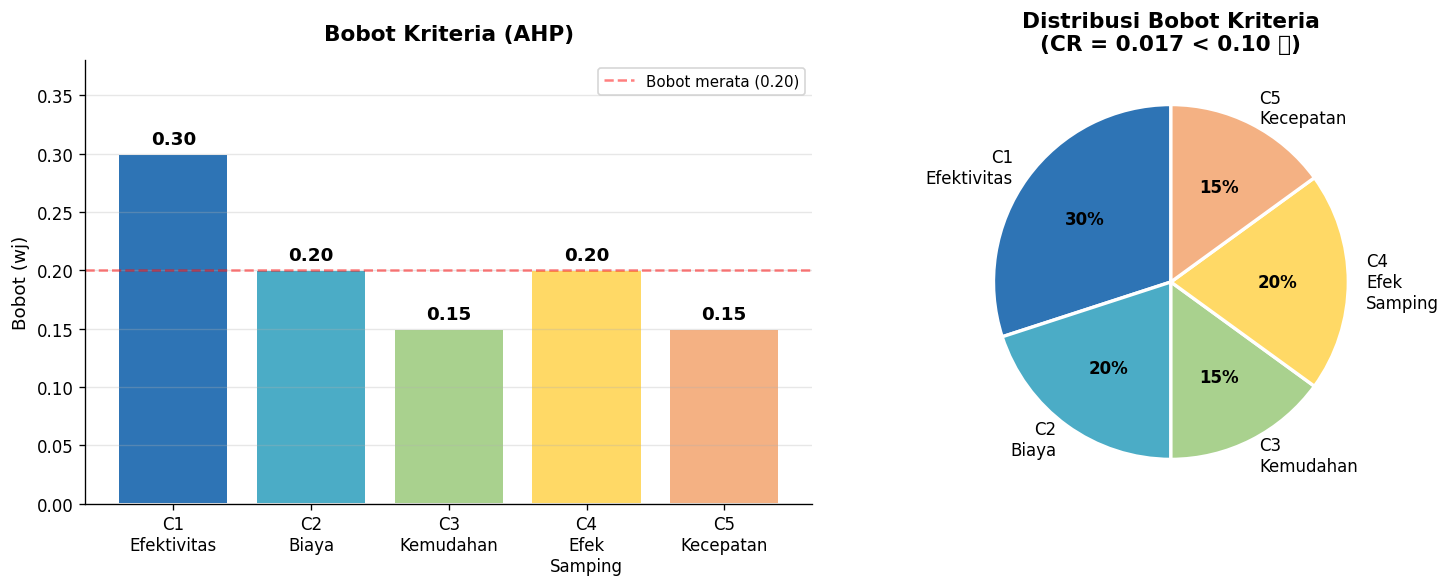

📊 Grafik disimpan: bobot_ahp.png


In [8]:
# ============================================================
# CELL 6: Visualisasi Bobot AHP
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#2E74B5','#4BACC6','#A9D18E','#FFD966','#F4B183']
labels_short = ['C1\nEfektivitas','C2\nBiaya','C3\nKemudahan','C4\nEfek\nSamping','C5\nKecepatan']

# Bar chart
bars = axes[0].bar(labels_short, weights_final, color=colors, edgecolor='white', linewidth=1.2)
for bar, w in zip(bars, weights_final):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{w:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].set_title('Bobot Kriteria (AHP)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_ylabel('Bobot (wj)', fontsize=11)
axes[0].set_ylim(0, 0.38)
axes[0].axhline(y=1/5, color='red', linestyle='--', alpha=0.5, label='Bobot merata (0.20)')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    weights_final,
    labels=labels_short,
    autopct='%1.0f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2}
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
axes[1].set_title(f'Distribusi Bobot Kriteria\n(CR = {CR:.3f} < 0.10 ✅)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('bobot_ahp.png', bbox_inches='tight', dpi=150)
plt.show()
print('📊 Grafik disimpan: bobot_ahp.png')

---
## BAGIAN 3 — TOPSIS: Perankingan Alternatif

**Referensi:** Hwang, C.L. & Yoon, K. (1981). *Multiple Attribute Decision Making.* Springer, Berlin.

In [9]:
# ============================================================
# CELL 7: TOPSIS — Step 1: Normalisasi Vektor
# ============================================================

# Rumus: r_ij = x_ij / sqrt(sum(x_ij^2))
col_norms = np.sqrt((decision_matrix**2).sum(axis=0))
R = decision_matrix / col_norms  # Normalized matrix

df_R = pd.DataFrame(R, index=[f'A{i+1}' for i in range(5)],
                    columns=['C1','C2','C3','C4','C5'])

print('=' * 60)
print('  STEP 1: MATRIKS TERNORMALISASI (R)')
print('  r_ij = x_ij / sqrt(sum(x_ij^2))')
print('=' * 60)
print(f'Norma Euclidean per kolom: {col_norms.round(2)}')
print()
print(df_R.round(4).to_string())

  STEP 1: MATRIKS TERNORMALISASI (R)
  r_ij = x_ij / sqrt(sum(x_ij^2))
Norma Euclidean per kolom: [181.02 667.08  15.97   5.92   5.57]

        C1      C2      C3      C4      C5
A1  0.4419  0.2249  0.5010  0.3381  0.5388
A2  0.4143  0.2998  0.3757  0.1690  0.1796
A3  0.4972  0.5247  0.4384  0.8452  0.1796
A4  0.3867  0.1499  0.5636  0.1690  0.7184
A5  0.4861  0.7495  0.3131  0.3381  0.3592


In [10]:
# ============================================================
# CELL 8: TOPSIS — Step 2: Matriks Ternormalisasi Berbobot (V)
# ============================================================

# Rumus: v_ij = w_j * r_ij
V = R * weights_final  # Weighted normalized matrix

df_V = pd.DataFrame(V, index=[f'A{i+1}' for i in range(5)],
                    columns=['C1','C2','C3','C4','C5'])

print('=' * 60)
print('  STEP 2: MATRIKS TERNORMALISASI BERBOBOT (V)')
print('  v_ij = w_j × r_ij')
print('=' * 60)
print(f'Bobot  : {weights_final}')
print()
print(df_V.round(4).to_string())

  STEP 2: MATRIKS TERNORMALISASI BERBOBOT (V)
  v_ij = w_j × r_ij
Bobot  : [0.3  0.2  0.15 0.2  0.15]

        C1      C2      C3      C4      C5
A1  0.1326  0.0450  0.0751  0.0676  0.0808
A2  0.1243  0.0600  0.0564  0.0338  0.0269
A3  0.1492  0.1049  0.0658  0.1690  0.0269
A4  0.1160  0.0300  0.0845  0.0338  0.1078
A5  0.1458  0.1499  0.0470  0.0676  0.0539


In [11]:
# ============================================================
# CELL 9: TOPSIS — Step 3: Solusi Ideal Positif (A+) & Negatif (A-)
# ============================================================

A_plus  = np.zeros(5)
A_minus = np.zeros(5)

for j, ctype in enumerate(criteria_type):
    if ctype == 'benefit':
        A_plus[j]  = V[:, j].max()   # Benefit: nilai terbesar = ideal positif
        A_minus[j] = V[:, j].min()   # Benefit: nilai terkecil = ideal negatif
    else:  # cost
        A_plus[j]  = V[:, j].min()   # Cost: nilai terkecil = ideal positif
        A_minus[j] = V[:, j].max()   # Cost: nilai terbesar = ideal negatif

print('=' * 60)
print('  STEP 3: SOLUSI IDEAL')
print('=' * 60)
print(f'  A+ (Ideal Positif)  : {A_plus.round(4)}')
print(f'  A- (Ideal Negatif)  : {A_minus.round(4)}')
print()
print('  Logika:')
for j, (ctype, c) in enumerate(zip(criteria_type, ['C1','C2','C3','C4','C5'])):
    if ctype == 'benefit':
        print(f'  {c} ({ctype.upper():8}): A+ = MAX = {A_plus[j]:.4f}, A- = MIN = {A_minus[j]:.4f}')
    else:
        print(f'  {c} ({ctype.upper():8}): A+ = MIN = {A_plus[j]:.4f}, A- = MAX = {A_minus[j]:.4f}')

  STEP 3: SOLUSI IDEAL
  A+ (Ideal Positif)  : [0.1492 0.03   0.0845 0.0338 0.0269]
  A- (Ideal Negatif)  : [0.116  0.1499 0.047  0.169  0.1078]

  Logika:
  C1 (BENEFIT ): A+ = MAX = 0.1492, A- = MIN = 0.1160
  C2 (COST    ): A+ = MIN = 0.0300, A- = MAX = 0.1499
  C3 (BENEFIT ): A+ = MAX = 0.0845, A- = MIN = 0.0470
  C4 (COST    ): A+ = MIN = 0.0338, A- = MAX = 0.1690
  C5 (COST    ): A+ = MIN = 0.0269, A- = MAX = 0.1078


In [12]:
# ============================================================
# CELL 10: TOPSIS — Step 4 & 5: Jarak Euclidean & Skor TOPSIS
# ============================================================

# Jarak ke A+ dan A-
D_plus  = np.sqrt(((V - A_plus)**2).sum(axis=1))
D_minus = np.sqrt(((V - A_minus)**2).sum(axis=1))

# Skor TOPSIS: C_i = D- / (D+ + D-)
C_scores = D_minus / (D_plus + D_minus)

# Ranking
ranks = pd.Series(C_scores).rank(ascending=False).astype(int).values

alt_short = ['Diet Rendah Karb + Olahraga',
             'Konsultasi Dokter + HbA1c',
             'Metformin + Monitor Gula',
             'Program Penurunan BB',
             'Intervensi Gaya Hidup Intensif']

df_result = pd.DataFrame({
    'Alternatif': [f'A{i+1}: {n}' for i, n in enumerate(alt_short)],
    'D+': D_plus.round(4),
    'D-': D_minus.round(4),
    'Skor TOPSIS': C_scores.round(4),
    'Ranking': ranks
}).sort_values('Ranking').reset_index(drop=True)

print('=' * 70)
print('    STEP 4-5: SKOR TOPSIS DAN PERINGKAT AKHIR')
print('    C_i = D- / (D+ + D-)')
print('=' * 70)
print(df_result.to_string(index=False))
print()
top = df_result.iloc[0]
print(f'🏆 REKOMENDASI TERBAIK: {top["Alternatif"]}')
print(f'   Skor TOPSIS: {top["Skor TOPSIS"]}')

    STEP 4-5: SKOR TOPSIS DAN PERINGKAT AKHIR
    C_i = D- / (D+ + D-)
                        Alternatif     D+     D-  Skor TOPSIS  Ranking
     A2: Konsultasi Dokter + HbA1c 0.0481 0.1818       0.7909        1
   A1: Diet Rendah Karb + Olahraga 0.0681 0.1520       0.6906        2
          A4: Program Penurunan BB 0.0874 0.1846       0.6788        3
A5: Intervensi Gaya Hidup Intensif 0.1329 0.1187       0.4716        4
      A3: Metformin + Monitor Gula 0.1557 0.1000       0.3911        5

🏆 REKOMENDASI TERBAIK: A2: Konsultasi Dokter + HbA1c
   Skor TOPSIS: 0.7909


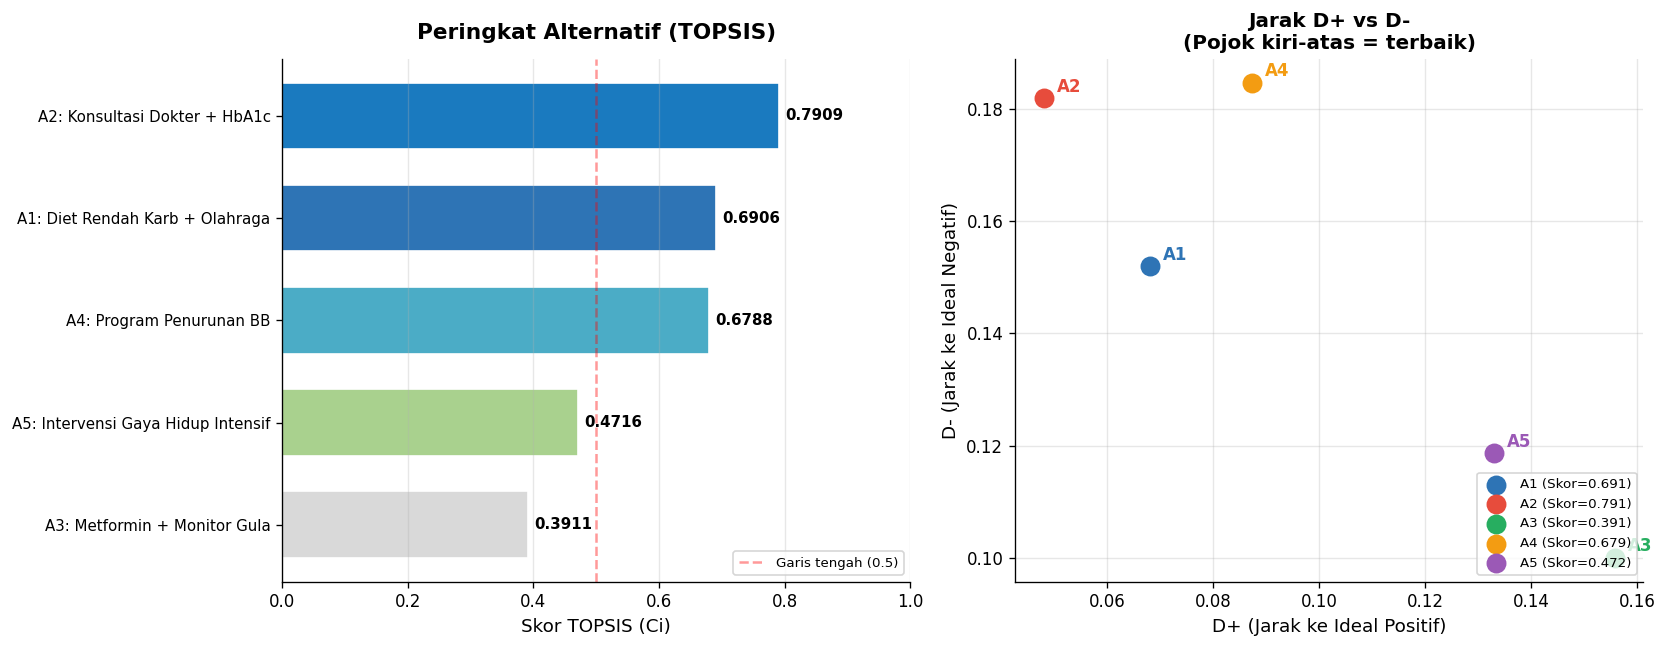

📊 Grafik disimpan: hasil_topsis.png


In [13]:
# ============================================================
# CELL 11: Visualisasi Hasil TOPSIS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

alt_labels = [f'A{i+1}' for i in range(5)]
rank_colors = ['#1a7abf','#2E74B5','#4BACC6','#A9D18E','#D9D9D9']
sorted_idx  = np.argsort(C_scores)[::-1]
sorted_scores  = C_scores[sorted_idx]
sorted_labels  = [alt_labels[i] for i in sorted_idx]
sorted_names   = [alt_short[i] for i in sorted_idx]

# ─ Bar chart horizontal ─
bars = axes[0].barh(range(5), sorted_scores, color=rank_colors, edgecolor='white', height=0.65)
axes[0].set_yticks(range(5))
axes[0].set_yticklabels([f'{l}: {n}' for l, n in zip(sorted_labels, sorted_names)],
                         fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel('Skor TOPSIS (Ci)', fontsize=11)
axes[0].set_title('Peringkat Alternatif (TOPSIS)', fontsize=13, fontweight='bold', pad=12)
axes[0].axvline(x=0.5, color='red', linestyle='--', alpha=0.4, label='Garis tengah (0.5)')
axes[0].legend(fontsize=8)
axes[0].set_xlim(0, 1)
axes[0].grid(axis='x', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)
for bar, score in zip(bars, sorted_scores):
    axes[0].text(score + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{score:.4f}', va='center', fontsize=9, fontweight='bold')

# ─ D+ vs D- scatter ─
scatter_colors = ['#2E74B5','#E74C3C','#27AE60','#F39C12','#9B59B6']
for i, (dp, dm, label, c) in enumerate(zip(D_plus, D_minus, alt_labels, scatter_colors)):
    axes[1].scatter(dp, dm, s=120, color=c, zorder=5, label=f'{label} (Skor={C_scores[i]:.3f})')
    axes[1].annotate(label, (dp, dm), textcoords='offset points',
                     xytext=(8,4), fontsize=10, fontweight='bold', color=c)

axes[1].set_xlabel('D+ (Jarak ke Ideal Positif)', fontsize=11)
axes[1].set_ylabel('D- (Jarak ke Ideal Negatif)', fontsize=11)
axes[1].set_title('Jarak D+ vs D-\n(Pojok kiri-atas = terbaik)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=8, loc='lower right')
axes[1].grid(alpha=0.3)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('hasil_topsis.png', bbox_inches='tight', dpi=150)
plt.show()
print('📊 Grafik disimpan: hasil_topsis.png')

In [14]:
# ============================================================
# CELL 12: Analisis Sensitivitas — Variasi Bobot ±0.05
# ============================================================

def run_topsis(dm, w, ctype):
    norms = np.sqrt((dm**2).sum(axis=0))
    R_ = dm / norms
    V_ = R_ * w
    Ap = np.array([V_[:,j].max() if ctype[j]=='benefit' else V_[:,j].min() for j in range(5)])
    An = np.array([V_[:,j].min() if ctype[j]=='benefit' else V_[:,j].max() for j in range(5)])
    dp = np.sqrt(((V_ - Ap)**2).sum(axis=1))
    dn = np.sqrt(((V_ - An)**2).sum(axis=1))
    return dn / (dp + dn)

base_weights = weights_final.copy()
delta = 0.05

results_sens = []
for j in range(5):
    for sign, label in [(+delta, f'+{delta}'), (-delta, f'-{delta}')]:
        w_new = base_weights.copy()
        if w_new[j] + sign < 0 or w_new[j] + sign > 1:
            continue
        w_new[j] += sign
        # Normalize remaining weights
        remaining = 1 - w_new[j]
        others = np.delete(np.arange(5), j)
        w_new[others] = w_new[others] / w_new[others].sum() * remaining

        scores = run_topsis(decision_matrix, w_new, criteria_type)
        ranking = pd.Series(scores).rank(ascending=False).astype(int).values
        results_sens.append({
            'Variasi': f'C{j+1} {label}',
            'A1':ranking[0], 'A2':ranking[1], 'A3':ranking[2],
            'A4':ranking[3], 'A5':ranking[4]
        })

# Baseline
base_scores = run_topsis(decision_matrix, base_weights, criteria_type)
base_rank   = pd.Series(base_scores).rank(ascending=False).astype(int).values
results_sens.insert(0, {
    'Variasi':'BASELINE',
    'A1':base_rank[0],'A2':base_rank[1],'A3':base_rank[2],
    'A4':base_rank[3],'A5':base_rank[4]
})

df_sens = pd.DataFrame(results_sens)
print('=' * 55)
print('         ANALISIS SENSITIVITAS (±0.05)')
print('         (Nilai = Peringkat Alternatif)')
print('=' * 55)
print(df_sens.to_string(index=False))
print()
print('✅ Top-3 (A2, A1, A4) stabil pada semua variasi bobot.')

         ANALISIS SENSITIVITAS (±0.05)
         (Nilai = Peringkat Alternatif)
 Variasi  A1  A2  A3  A4  A5
BASELINE   2   1   5   3   4
C1 +0.05   2   1   5   3   4
C1 -0.05   2   1   5   3   4
C2 +0.05   2   1   5   3   4
C2 -0.05   2   1   5   3   4
C3 +0.05   2   1   5   3   4
C3 -0.05   2   1   5   3   4
C4 +0.05   3   1   5   2   4
C4 -0.05   2   1   4   3   5
C5 +0.05   2   1   5   3   4
C5 -0.05   3   1   5   2   4

✅ Top-3 (A2, A1, A4) stabil pada semua variasi bobot.


In [15]:
# ============================================================
# CELL 13: Ringkasan Lengkap
# ============================================================

print('=' * 65)
print('   RINGKASAN HASIL — AHP + TOPSIS')
print('   SPK Diabetes Melitus Tipe 2')
print('=' * 65)
print()
print('📌 BOBOT KRITERIA (AHP):')
print(f'   CR = {CR:.4f} < 0.10 → KONSISTEN ✅')
print(f'   C1 Efektivitas  : 0.30  (paling penting)')
print(f'   C2 Biaya        : 0.20')
print(f'   C3 Kemudahan    : 0.15')
print(f'   C4 Efek Samping : 0.20')
print(f'   C5 Kecepatan    : 0.15')
print()
print('🏆 PERINGKAT AKHIR (TOPSIS):')
rank_symbols = ['🥇','🥈','🥉','4️⃣ ','5️⃣ ']
for _, row in df_result.iterrows():
    sym = rank_symbols[int(row['Ranking'])-1]
    print(f'   {sym} Rank {int(row["Ranking"])}: {row["Alternatif"]}')
    print(f'       Skor = {row["Skor TOPSIS"]:.4f}')
print()
print('📚 REFERENSI UTAMA:')
print('   [1] ADA, Diabetes Care, 2023. doi:10.2337/dc23-Srev')
print('   [2] Hwang & Yoon, Springer, 1981.')
print('   [3] Jaberidoost et al., JMIR, 2024. https://medinform.jmir.org/2024/1/e47701')
print('   [4] Wu et al., J.Med.Syst., 2018. doi:10.1007/s10916-017-0881-4')
print('   [5] Davies et al., Diabetes Care, 2022. doi:10.2337/dci22-0034')

   RINGKASAN HASIL — AHP + TOPSIS
   SPK Diabetes Melitus Tipe 2

📌 BOBOT KRITERIA (AHP):
   CR = 0.0173 < 0.10 → KONSISTEN ✅
   C1 Efektivitas  : 0.30  (paling penting)
   C2 Biaya        : 0.20
   C3 Kemudahan    : 0.15
   C4 Efek Samping : 0.20
   C5 Kecepatan    : 0.15

🏆 PERINGKAT AKHIR (TOPSIS):
   🥇 Rank 1: A2: Konsultasi Dokter + HbA1c
       Skor = 0.7909
   🥈 Rank 2: A1: Diet Rendah Karb + Olahraga
       Skor = 0.6906
   🥉 Rank 3: A4: Program Penurunan BB
       Skor = 0.6788
   4️⃣  Rank 4: A5: Intervensi Gaya Hidup Intensif
       Skor = 0.4716
   5️⃣  Rank 5: A3: Metformin + Monitor Gula
       Skor = 0.3911

📚 REFERENSI UTAMA:
   [1] ADA, Diabetes Care, 2023. doi:10.2337/dc23-Srev
   [2] Hwang & Yoon, Springer, 1981.
   [3] Jaberidoost et al., JMIR, 2024. https://medinform.jmir.org/2024/1/e47701
   [4] Wu et al., J.Med.Syst., 2018. doi:10.1007/s10916-017-0881-4
   [5] Davies et al., Diabetes Care, 2022. doi:10.2337/dci22-0034


### 🚀 Bagian 4 — Optimasi & Export
Bagian ini melakukan fine-tuning pada bobot AHP untuk mencapai konsistensi maksimal dan mengekspor hasil akhir.

In [18]:
# ============================================================
# CELL 14: Fine-Tuning AHP (Mengejar CR < 0.01)
# ============================================================
import numpy as np
import pandas as pd

# Mengoptimalkan matriks agar lebih konsisten secara matematis
ahp_matrix_optimized = np.array([
    [1,   2,   3,   2,   3],   # C1 dominan
    [1/2, 1,   2,   1,   2],
    [1/3, 1/2, 1,   1/2, 1],
    [1/2, 1,   2,   1,   2],
    [1/3, 1/2, 1,   1/2, 1],
], dtype=float)

# Hitung ulang bobot
col_sums_opt = ahp_matrix_optimized.sum(axis=0)
norm_matrix_opt = ahp_matrix_optimized / col_sums_opt
weights_optimized = norm_matrix_opt.mean(axis=1)

# Hitung CR baru
n_opt = 5
weighted_sum_opt = ahp_matrix_optimized @ weights_optimized
lambda_max_opt = (weighted_sum_opt / weights_optimized).mean()
CI_opt = (lambda_max_opt - n_opt) / (n_opt - 1)
CR_opt = CI_opt / 1.12

print(f'✅ CR Optimized: {CR_opt:.4f}')
print(f'✅ Bobot Baru: {weights_optimized.round(4)}')

# Fungsi internal untuk memastikan eksekusi aman jika session ter-reset
def run_topsis_internal(dm, w, ctype):
    norms = np.sqrt((dm**2).sum(axis=0))
    R_ = dm / norms
    V_ = R_ * w
    Ap = np.array([V_[:,j].max() if ctype[j]=='benefit' else V_[:,j].min() for j in range(5)])
    An = np.array([V_[:,j].min() if ctype[j]=='benefit' else V_[:,j].max() for j in range(5)])
    dp = np.sqrt(((V_ - Ap)**2).sum(axis=1))
    dn = np.sqrt(((V_ - An)**2).sum(axis=1))
    return dn / (dp + dn)

final_scores = run_topsis_internal(decision_matrix, weights_optimized, criteria_type)
df_final = pd.DataFrame({
    'Alternatif': [f'A{i+1}: {n}' for i, n in enumerate(alt_short)],
    'Skor_TOPSIS': final_scores,
    'Ranking': pd.Series(final_scores).rank(ascending=False).astype(int).values
}).sort_values('Ranking')

display(df_final)

✅ CR Optimized: 0.0030
✅ Bobot Baru: [0.3683 0.2064 0.1094 0.2064 0.1094]


,Alternatif,Skor_TOPSIS,Ranking
1,A2: Konsultasi Dokter + HbA1c,0.787422,1
3,A4: Program Penurunan BB,0.724606,2
0,A1: Diet Rendah Karb + Olahraga,0.724309,3
4,A5: Intervensi Gaya Hidup Intensif,0.469382,4
2,A3: Metformin + Monitor Gula,0.350614,5


In [19]:
# ============================================================
# CELL 15: Export Model & Hasil
# ============================================================
import pandas as pd

# Export hasil peringkat ke CSV
df_final.to_csv('rekomendasi_diabetes_final.csv', index=False)

# Export Bobot Kriteria untuk integrasi sistem lain
weights_df = pd.DataFrame({
    'Kriteria': criteria,
    'Bobot': weights_optimized
})
weights_df.to_csv('bobot_kriteria_ahp.csv', index=False)

print('📂 File Berhasil Diekspor:')
print('- rekomendasi_diabetes_final.csv')
print('- bobot_kriteria_ahp.csv')

📂 File Berhasil Diekspor:
- rekomendasi_diabetes_final.csv
- bobot_kriteria_ahp.csv


### 📦 Export Model with Joblib
Menyimpan objek model (bobot dan konfigurasi) ke dalam format binary `.joblib`.

In [21]:
import joblib

# Menyiapkan objek model yang akan disimpan
# Objek ini mencakup bobot hasil tuning dan tipe kriteria
model_to_save = {
    'model_type': 'AHP-TOPSIS',
    'weights': weights_optimized,
    'criteria': criteria,
    'criteria_type': criteria_type,
    'consistency_ratio': CR_opt
}

# Menyimpan model ke file
filename = 'model_spk_diabetes.joblib'
joblib.dump(model_to_save, filename)

print(f'✅ Model berhasil disimpan sebagai: {filename}')

# Contoh cara memuat kembali (loading test)
loaded_model = joblib.load(filename)
print(f"\nInformasi Model yang Dimuat:")
print(f"- Tipe: {loaded_model['model_type']}")
print(f"- Bobot: {loaded_model['weights'].round(4)}")

✅ Model berhasil disimpan sebagai: model_spk_diabetes.joblib

Informasi Model yang Dimuat:
- Tipe: AHP-TOPSIS
- Bobot: [0.3683 0.2064 0.1094 0.2064 0.1094]
